In [28]:
from dataset.dataset import load_data, visualize_k_samples

train_set, val_set, test_set = load_data(
    "DecoyFashionMNIST", 
    seed=123, 
    reload=True,
    bias_ratio=[0.99]*10,
    variation=2
  )



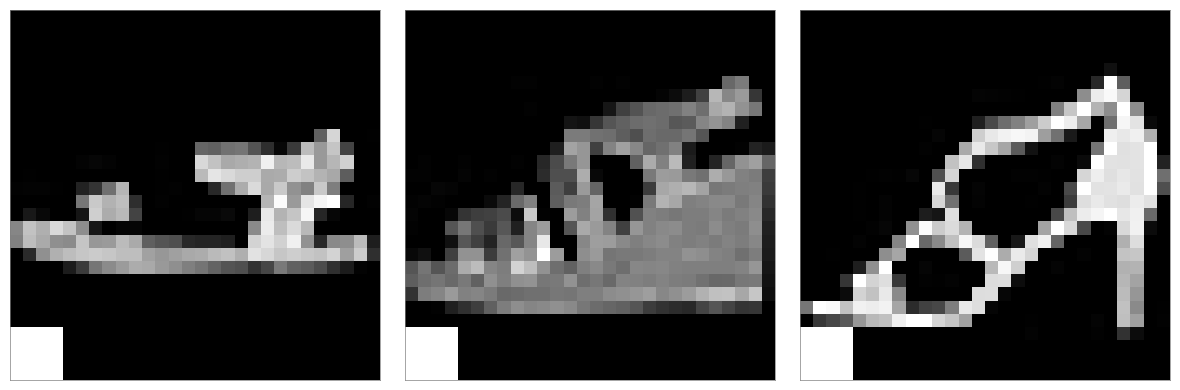

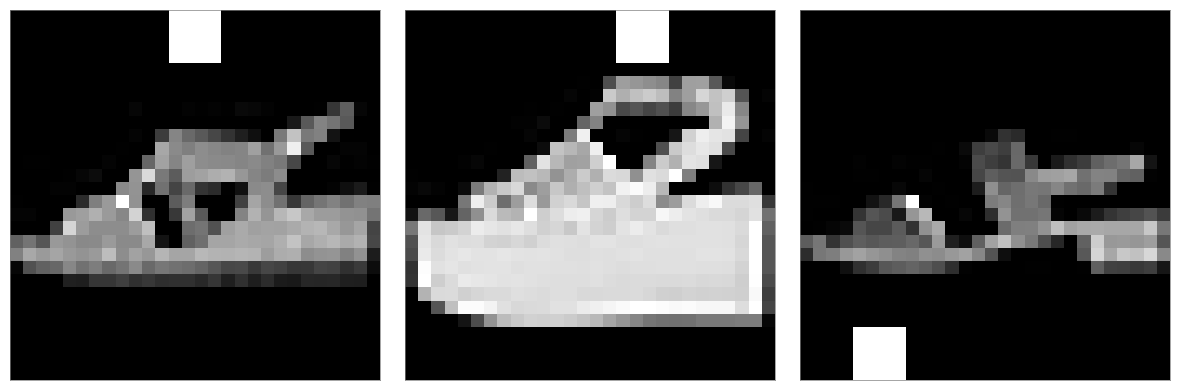

In [29]:
visualize_k_samples(dataset=train_set, label=5, k=3)
visualize_k_samples(dataset=test_set, label=5, k=3)

In [ ]:
# Visualize if model is confounded
import torch
import numpy as np
from model.model import load_model
from dataset.dataset import load_data, create_dataloaders
from functions.optimizer import load_optimizer
from functions.loss import load_loss_fun
from functions.functions import train_model, eval_model, save_checkpoint, load_checkpoint
from functions.xai import explain_dataset, visualize_k_expl
from utils.utils import enable_reproducibility

def see_explainations(model_name, dataset, bias_ratio,conf_type, seed=123):
  use_cuda = torch.cuda.is_available()
  device = 'cuda' if use_cuda else 'cpu'
  enable_reproducibility(seed)

  model = load_model(model_name, device=device)
  optim = load_optimizer("SGD", model.parameters(), lr=1e-2, weight_decay=0)
  loss = load_loss_fun("CrossEntropy")

  train_set, val_set, test_set = load_data(
    dataset, 
    seed=seed, 
    reload=True,
    bias_ratio=bias_ratio,
    variation=conf_type
  )
  
  data = [train_set, val_set, test_set]
  params = {"batch_size":32}
  m_params = [params]*3
  train_loader, val_loader, test_loader = create_dataloaders(data, m_params)

  _, _ = train_model(
    model=model, 
    train_loader=train_loader, 
    optimizer=optim, 
    loss_fun=loss, 
    n_epochs=10, 
    eval_loader=val_loader, 
    device=device
  )
  attrs, imgs = explain_dataset(train_loader, model, device)
  for cls in range(10):
    visualize_k_expl(attrs, imgs, train_loader, cls, 3)

In [ ]:
see_explainations(
  "ModernLeNet", 
  "DecoyMNIST", 
  [0,0.5,0,0,0,0.5,0,0,0.5,0.5],
  2,
  123
  )